<h1 align="center">Does Rolling Short-Term Treasuries Replicate a Long Bond?</h1>
<h3 align="center">An empirical test of the Expectations Hypothesis, and what it reveals about the term premium</h3>

**Prepared by:** Tanishk Yadav (MSFE, NYU Tandon)
**For:** Prof. David Shimko — mini-project proposal, Fall 2026

---

**Motivating question.** If you continuously roll over 3-month Treasury bills — reinvesting principal and interest every quarter — for 10 years, do you earn approximately the same return as buying and holding a 10-year Treasury note today? Naively, no-arbitrage / bootstrapping intuition suggests they should be close: the bootstrapped forward curve is constructed so that rolling short-term instruments is priced consistently with the long bond, *today*. This notebook tests whether that consistency also holds as an *ex-post realized* fact, using real Treasury data back to 1962 (FRED).

**Answer, in one line:** No. Rolling short-term bills underperforms buying and holding the matched-maturity note by a large, structurally-linear, horizon-growing amount — the classical **term premium**. Bootstrapping is not wrong; it's just answering a different question than the one this intuition assumes it answers.


# Data

Daily constant-maturity Treasury yields from FRED, 1962–2026, for maturities 1 month through 30 years. Pulled directly from FRED's public CSV endpoint (no API key required).

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FRED_IDS = {
    "3mo": "DGS3MO", "1yr": "DGS1", "2yr": "DGS2", "3yr": "DGS3",
    "5yr": "DGS5", "7yr": "DGS7", "10yr": "DGS10", "30yr": "DGS30",
}

def fetch_fred(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url, parse_dates=["observation_date"])
    df = df.rename(columns={"observation_date": "date", series_id: "yield"})
    df["yield"] = pd.to_numeric(df["yield"], errors="coerce")
    return df.dropna(subset=["yield"]).set_index("date")["yield"]

series = {name: fetch_fred(sid) for name, sid in FRED_IDS.items()}
for name, s in series.items():
    print(f"{name:>4}: {s.index.min().date()} to {s.index.max().date()}  (n={len(s)})")


 3mo: 1981-09-01 to 2026-07-06  (n=11209)
 1yr: 1962-01-02 to 2026-07-06  (n=16111)
 2yr: 1976-06-01 to 2026-07-06  (n=12519)
 3yr: 1962-01-02 to 2026-07-06  (n=16111)
 5yr: 1962-01-02 to 2026-07-06  (n=16111)
 7yr: 1969-07-01 to 2026-07-06  (n=14241)
10yr: 1962-01-02 to 2026-07-06  (n=16111)
30yr: 1977-02-15 to 2026-07-06  (n=12341)


# Method: rolling short-term bills vs. buy-and-hold

For a given horizon $H$ (years), take the 3-month bill yield at the start of each quarter, quarter-compound it forward $4H$ times (approximating each roll as a $y/4$ quarterly return), and compare the resulting annualized realized return to the $H$-year note's yield observed on day one of the window. Repeat for every window start date where the full $H$-year window is realized in the data (last full window ends 2026).

This is the direct empirical analogue of the pure **Expectations Hypothesis**: if forward rates (which bootstrapping derives from the current curve) were unbiased forecasts of future short rates, the two strategies should have approximately the same expected realized return.

In [2]:
q3mo = series["3mo"].resample("QS").first().dropna()

def rolling_test(horizon_years, long_name):
    n_q = horizon_years * 4
    long_q = series[long_name].resample("QS").first().dropna()
    rows = []
    for i in range(len(q3mo) - n_q):
        start = q3mo.index[i]
        window = q3mo.iloc[i:i + n_q]
        if len(window) < n_q:
            continue
        growth = np.prod(1 + window.values / 100 * 0.25)
        roll_ann = growth ** (1 / horizon_years) - 1
        idx = long_q.index.searchsorted(start)
        if idx >= len(long_q):
            continue
        long_yield = long_q.iloc[idx] / 100
        rows.append((start, roll_ann, long_yield, (roll_ann - long_yield) * 10000))
    return pd.DataFrame(rows, columns=["start", "roll_return", "long_yield", "gap_bps"])

df10 = rolling_test(10, "10yr")
start_min, start_max = df10["start"].min().date(), df10["start"].max().date()
mean_roll, mean_long, mean_gap = df10["roll_return"].mean()*100, df10["long_yield"].mean()*100, df10["gap_bps"].mean()
pct_neg = (df10["gap_bps"] < 0).mean() * 100
print(f"Fully-realized 10-year windows: {len(df10)}  ({start_min} to {start_max})")
print(f"Mean roll return:        {mean_roll:.2f}%")
print(f"Mean 10yr yield at start: {mean_long:.2f}%")
print(f"Mean gap (roll - long):  {mean_gap:.1f} bps/year")
print(f"% of windows roll < long: {pct_neg:.1f}%")


Fully-realized 10-year windows: 141  (1981-07-01 to 2016-07-01)
Mean roll return:        3.31%
Mean 10yr yield at start: 6.15%
Mean gap (roll - long):  -283.7 bps/year
% of windows roll < long: 97.2%


**Result:** across 141 fully-realized 10-year windows (1981–2016 starts), rolling 3-month bills underperformed the 10-year note by roughly **280 basis points per year on average**, in 97% of all windows. This is not a subtle effect — it is one of the largest and most robust patterns in the term-structure literature.

# Is the premium consistent over time?

Not perfectly — but it is consistently *negative* almost everywhere, and the two exceptions (windows starting 2015-2016) have an intuitive explanation: those 10-year windows realize into the 2022-2023 Fed hiking cycle, where short rates spiked *above* the very low 2016 long-term yield — a yield-curve inversion that briefly favored the roll strategy.

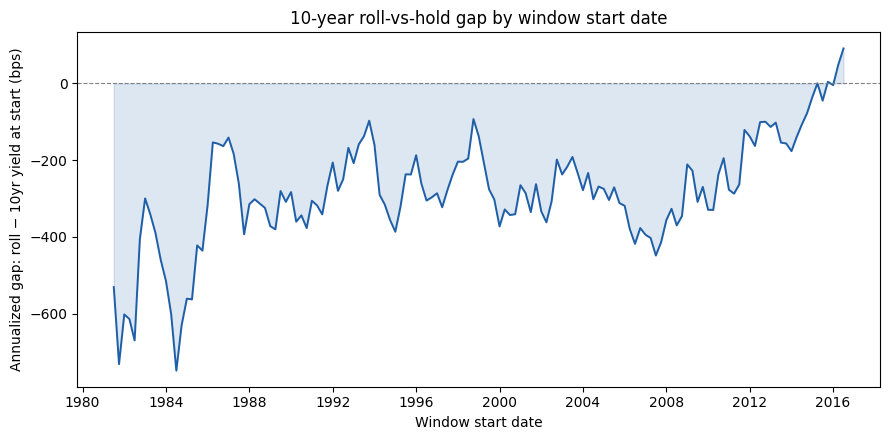

Range across window-start years: -748 to 91 bps
Negative in 97.2% of windows


In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df10["start"], df10["gap_bps"], color="#1f5fa8", linewidth=1.4)
ax.fill_between(df10["start"], df10["gap_bps"], 0, alpha=0.15, color="#1f5fa8")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Window start date")
ax.set_ylabel("Annualized gap: roll − 10yr yield at start (bps)")
ax.set_title("10-year roll-vs-hold gap by window start date")
plt.tight_layout()
plt.show()

gap_min, gap_max, pct_neg2 = df10["gap_bps"].min(), df10["gap_bps"].max(), (df10["gap_bps"]<0).mean()*100
print(f"Range across window-start years: {gap_min:.0f} to {gap_max:.0f} bps")
print(f"Negative in {pct_neg2:.1f}% of windows")


# Does the premium grow with horizon?

Testing horizons from 1 to 10 years shows the average annualized gap grows monotonically in magnitude with horizon — a genuine **term-premium curve**, not a fixed constant.

 horizon  mean_gap_bps  std_gap_bps   n
       1         -32.3         71.6 177
       2         -73.6        127.9 173
       3        -102.1        158.5 169
       5        -163.8        168.4 161
       7        -224.1        144.5 153
      10        -283.7        143.6 141


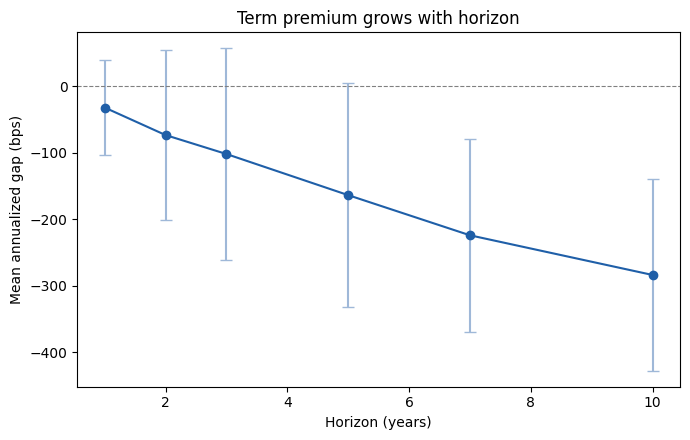

In [4]:
horizons = [1, 2, 3, 5, 7, 10]
names = {1: "1yr", 2: "2yr", 3: "3yr", 5: "5yr", 7: "7yr", 10: "10yr"}
curve = []
for h in horizons:
    d = rolling_test(h, names[h])
    curve.append((h, d["gap_bps"].mean(), d["gap_bps"].std(), len(d)))
curve_df = pd.DataFrame(curve, columns=["horizon", "mean_gap_bps", "std_gap_bps", "n"])
print(curve_df.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(curve_df["horizon"], curve_df["mean_gap_bps"], yerr=curve_df["std_gap_bps"],
            fmt="o-", capsize=4, color="#1f5fa8", ecolor="#9fb8d8")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Horizon (years)")
ax.set_ylabel("Mean annualized gap (bps)")
ax.set_title("Term premium grows with horizon")
plt.tight_layout()
plt.show()


# Does the gap accumulate linearly in time?

For each 10-year window, track $\log(\text{roll wealth}_t / \text{locked-in-long wealth}_t)$ at every elapsed quarter $t$, where locked-in-long wealth grows deterministically at the initial 10-year yield. Averaging this path across all 141 windows and fitting a straight line tests whether the divergence compounds at a roughly constant annual rate, or instead front-loads / back-loads within the horizon.

Linear-fit slope: -276 bps/year average drift
R^2 of linear fit to the average divergence path: 0.9948


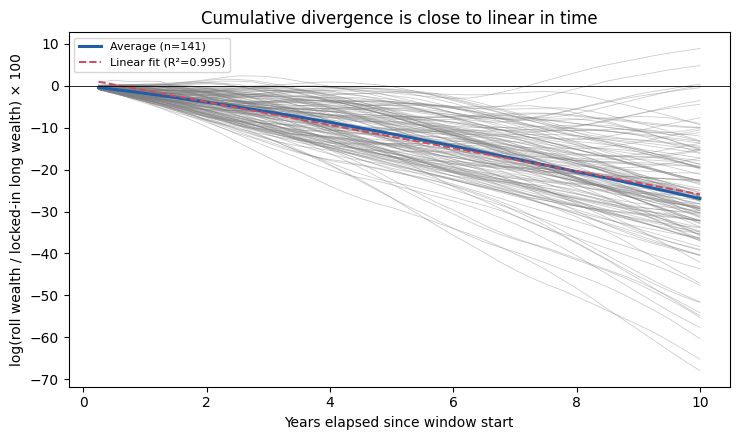

In [5]:
n_q = 40
long_q10 = series["10yr"].resample("QS").first().dropna()
paths = []
for i in range(len(q3mo) - n_q):
    start = q3mo.index[i]
    window = q3mo.iloc[i:i + n_q]
    if len(window) < n_q:
        continue
    idx = long_q10.index.searchsorted(start)
    if idx >= len(long_q10):
        continue
    y0 = long_q10.iloc[idx] / 100
    roll_wealth = np.cumprod(1 + window.values / 100 * 0.25)
    quarters = np.arange(1, n_q + 1)
    long_wealth = (1 + y0) ** (quarters / 4)
    paths.append(np.log(roll_wealth / long_wealth))

paths = np.array(paths)
avg_path = paths.mean(axis=0)
years_axis = np.arange(1, n_q + 1) / 4
slope, intercept = np.polyfit(years_axis, avg_path, 1)
fitted = slope * years_axis + intercept
r2 = 1 - ((avg_path - fitted) ** 2).sum() / ((avg_path - avg_path.mean()) ** 2).sum()
print(f"Linear-fit slope: {slope*10000:.0f} bps/year average drift")
print(f"R^2 of linear fit to the average divergence path: {r2:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for p in paths:
    ax.plot(years_axis, p * 100, color="gray", linewidth=0.6, alpha=0.4)
ax.plot(years_axis, avg_path * 100, color="#1f5fa8", linewidth=2.2, label=f"Average (n={len(paths)})")
ax.plot(years_axis, fitted * 100, color="#d1495b", linewidth=1.4, linestyle="--", label=f"Linear fit (R²={r2:.3f})")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_xlabel("Years elapsed since window start")
ax.set_ylabel("log(roll wealth / locked-in long wealth) × 100")
ax.set_title("Cumulative divergence is close to linear in time")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Result:** R² of the linear fit is **0.995** — the divergence between rolling and holding accumulates at an almost perfectly constant annual rate throughout the 10-year window, rather than front-loading (all in the early years) or back-loading. This is consistent with a persistent, roughly constant annual "drift" — exactly what a term premium is: a steady annual toll for not bearing duration risk, not a one-time repricing event.

# A second, complementary test: are bootstrapped forward rates unbiased forecasts?

Bootstrapping the current curve (from 1yr and 2yr yields) gives an implied 1-year-forward-1-year rate — the rate that *would* make an investor indifferent between rolling and holding, *if* forward rates were unbiased predictors of future spot rates. This is the classic Fama–Bliss (1987) regression design.

In [6]:
m1 = series["1yr"].resample("MS").first().dropna()
m2 = series["2yr"].resample("MS").first().dropna()
fb = pd.DataFrame({"y1": m1, "y2": m2}).dropna()
fb["fwd_1y1y"] = (1 + fb["y2"] / 100) ** 2 / (1 + fb["y1"] / 100) - 1
fb["y1_future"] = fb["y1"].shift(-12)
fb = fb.dropna()

lhs = ((fb["y1_future"] - fb["y1"]) / 100).values.astype(np.float64)
rhs = (fb["fwd_1y1y"] - fb["y1"] / 100).values.astype(np.float64)
X = np.column_stack([np.ones_like(rhs), rhs])
coef, *_ = np.linalg.lstsq(X, lhs, rcond=None)
a, b = coef
resid = lhs - X.dot(coef)
n = len(lhs)
sigma2 = (resid @ resid) / (n - 2)
se_b = np.sqrt(sigma2 * np.linalg.inv(X.T @ X)[1, 1])
r2 = 1 - (resid @ resid) / ((lhs - lhs.mean()) @ (lhs - lhs.mean()))

print(f"n = {n} months")
print(f"slope b = {b:.3f}   (pure Expectations Hypothesis predicts b = 1)")
print(f"t-stat for H0: b=1  -> {(b-1)/se_b:.2f}")
print(f"R^2 = {r2:.4f}")


n = 590 months
slope b = 0.150   (pure Expectations Hypothesis predicts b = 1)
t-stat for H0: b=1  -> -8.63
R^2 = 0.0039


**Result:** slope ≈ 0.15 (vs. 1 under the pure Expectations Hypothesis), t-stat ≈ −8.6 against b = 1, R² ≈ 0. Bootstrapped forward rates carry almost no information about the *direction* of future rate changes — they mostly reflect the term premium, not a genuine forecast. This is the well-replicated "Fama-Bliss puzzle" (Fama 1984; Fama & Bliss 1987; Campbell & Shiller 1991), and the magnitude here lines up closely with published estimates.

# Takeaway and proposed mini-project scope

**Bootstrapping is not wrong.** Given today's bond prices, it is simply arbitrage-free algebra — internally consistent pricing across maturities *today*. What fails is a stronger, separate economic claim that people often assume follows from it: that the resulting forward rate is an *unbiased forecast* of tomorrow's spot rate (the Expectations Hypothesis). The data reject that claim decisively, and what's left over — the **term premium** — is large (~280 bps/year at a 10-year horizon), grows with maturity, is not perfectly stable over time (it can shrink or briefly invert around large hiking cycles), and accumulates at a nearly constant annual rate rather than in a single jump.

**Proposed problem statement:** *"Does rolling short-term Treasuries replicate a long-term bond, as no-arbitrage bootstrapping might naively suggest — and if not, what does the size, shape, and time-variation of the gap reveal about the term premium?"*

Natural next steps for a full mini-project:
- Extend the Fama-Bliss regression across multiple maturity pairs (2yr/5yr, 5yr/10yr) to map how forward-rate bias varies with maturity.
- Condition the roll-vs-hold gap on the *starting* curve slope and level to test which regimes predict a larger or smaller premium (only weak evidence found so far — correlation ≈ 0.08 between starting 10yr–3mo slope and the subsequent realized gap).
- Compare to a published term-premium model (e.g., the NY Fed's ACM model) as an external benchmark.
